In [88]:
# magics: ensures that any changes to the modules loaded below will be re-loaded automatically
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import os
import sys
#sys.path.append('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Job Search/')
sys.path.append('/Users/albertolsen/Documents/Stud Polit/9. semester/Dynamic Programming/Exam/termpaper_dynprog/Job Search')
#print(os.getcwd())
#print(os.listdir("/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Job Search"))
import Model_components as model
import numpy as np
from time import process_time
import matplotlib.pyplot as plt
from scipy import interpolate 
import optimagic as om
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import pandas as pd
import scipy.optimize as opt
from scipy.optimize import fsolve
from scipy.stats import beta
# from numba import njit, vectorize


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [90]:
import os
cwd = os.getcwd()
print(repr(cwd))   # repr() shows the raw string, including any hidden characters
print(len(cwd))     # shows the actual character count

'/Users/albertolsen/Documents/Stud Polit/9. semester/Dynamic Programming/Exam/termpaper_dynprog'
94


In [60]:
delta = 0.93
gamma = 0.9
eta = 1
k = 300
k1 = 300
k2 = 250
k3 = 200
q1 = 0.3
q2 = 0.3
lmbda = 4.9
N = 6

abar = [0, 1000]

n_a = 50
n_c = 100
T1 = 6
T2 = 18
T3 = 24
T = 44
b1= 222
b2 = 222
b3 = 114 
welfare = 90
w = 675
R = 0.01


In [61]:
params = np.array([delta, gamma, eta, k, lmbda, N])
params_multi = np.array([delta, gamma, eta, k1, k2, k3, q1, q2,lmbda, N])
institutions_pre = np.array([ n_a, n_c, T1, T2, T3, T, b1, b2, b3, welfare, w, R])
b1 = 342
b2 = 171
institutions_post = np.array([ n_a, n_c, T1, T2, T3, T, b1, b2, b3, welfare, w, R])

# Asset grid
a_grid = np.linspace(abar[0], abar[1], n_a)

# Scale asset grid to [0,1]
x = (a_grid - abar[0]) / (abar[1] - abar[0])

# Plausible right-skewed asset distribution
alpha = 1.5
beta_param = 4.0

weights = beta.pdf(x, alpha, beta_param)

# Normalize so weights sum to 1
weights = weights / weights.sum()

In [62]:

a_grid = np.linspace(abar[0], abar[1], n_a)

# Convert grid to [0,1]
x = (a_grid - abar[0]) / (abar[1] - abar[0])

# Bin boundaries halfway between grid points
edges = np.empty(n_a + 1)
edges[1:-1] = (x[:-1] + x[1:]) / 2
edges[0] = 0
edges[-1] = 1

alpha = 1.5
beta_param = 4.0

# Probability mass in each bin
weights = np.diff(beta.cdf(edges, alpha, beta_param))

weights /= weights.sum()

In [63]:
S, V_emp, V_unemp, c_emp, c_unemp, Vss_emp, Vss_uemp, css_emp, css_uemp, survival, benefits = model.SolveModel(params, institutions_pre, abar)

Optimal consumption of assets solved in 280 iterations, using 0.04708 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04361 seconds


In [64]:
#S, V_emp, V_unemp, c_emp, c_unemp, Vss_emp, Vss_uemp, css_emp, css_uemp, survival, benefits = model.SolveModel(delta, gamma, eta, k, lmbda, N abar, n_a, n_c, T1, T2, T3, T , b1, b2, b3, welfare, w, R)

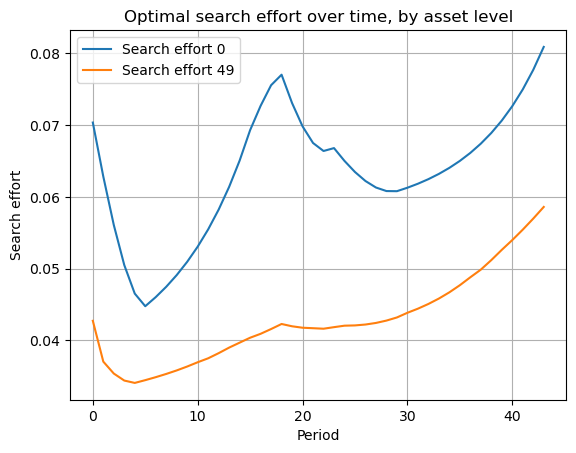

In [65]:
plt.plot(S[0,:-1], label="Search effort 0")
plt.plot(S[49,:-1], label="Search effort 49")
#plt.plot(S[10,:], label="Search")
plt.xlabel("Period")
plt.ylabel("Search effort")
plt.title("Optimal search effort over time, by asset level")
plt.legend()
plt.grid(True)
plt.show()

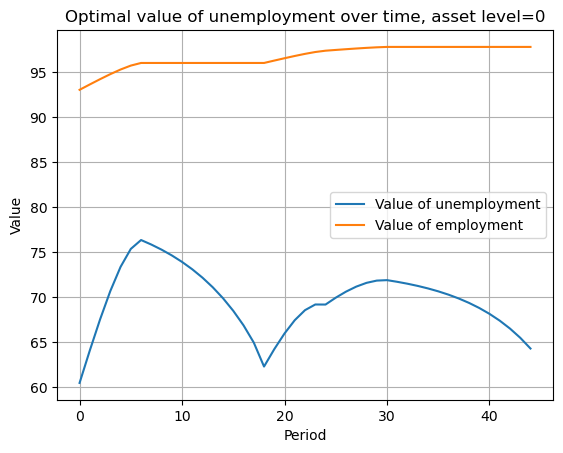

In [66]:
plt.plot(V_unemp[0,:], label="Value of unemployment")
plt.plot(V_emp[0,:], label="Value of employment")
#plt.plot(S[10,:], label="Search")
plt.xlabel("Period")
plt.ylabel("Value")
plt.title("Optimal value of unemployment over time, asset level=0")
plt.legend()
plt.grid(True)
plt.show()

In [67]:
moments = model.simulate_moments(params, institutions_pre, institutions_post, abar, weights)
timevec = np.arange((len(moments))/2)*15 + 15

Optimal consumption of assets solved in 280 iterations, using 0.14568 seconds
Optimal consumption of assets solved in 275 iterations, using 0.13847 seconds
Optimal consumption of assets solved in 280 iterations, using 0.10243 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04624 seconds


In [68]:
# Create target (empirical moments) and covariance matrix
target, cov = model.matchingMoments()

# Create weighting function
W = np.linalg.inv(cov)



In [69]:
# Create SSE, distance measure
SSE = model.sse(params, target, W, institutions_pre, institutions_post, abar, weights)

Optimal consumption of assets solved in 280 iterations, using 0.50522 seconds
Optimal consumption of assets solved in 275 iterations, using 0.50392 seconds
Optimal consumption of assets solved in 280 iterations, using 0.56495 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04707 seconds


In [70]:
print(f'SSE (Goodness of Fit): {SSE}')

SSE (Goodness of Fit): 1644.0815091963705


In [71]:
def split_half(arr):
    mid = len(arr) // 2
    return arr[:mid], arr[mid:]

pre, post = split_half(moments)


emp_pre, emp_post = split_half(target)


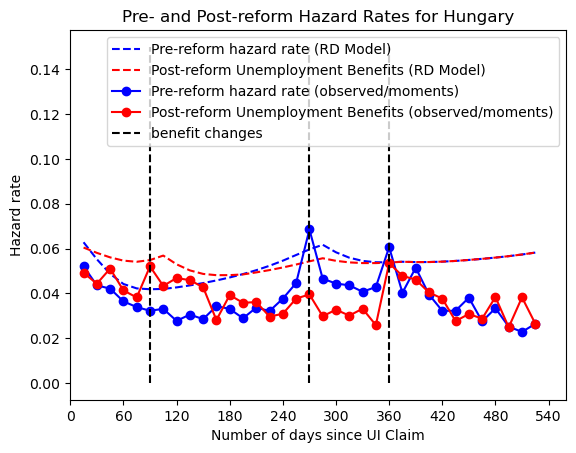

In [72]:
plt.plot(timevec, pre, label='Pre-reform hazard rate (RD Model)', linestyle='dashed', color='blue')
plt.plot(timevec, post, label='Post-reform Unemployment Benefits (RD Model)', linestyle='dashed', color='red')
plt.plot(timevec, emp_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='blue')
plt.plot(timevec, emp_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='red')

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[6*15, 18*15, 24*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.show()

In [73]:
fixed_params = params

In [74]:
sse1 = model.sse(fixed_params, target, W, institutions_pre, institutions_post, abar, weights)

Optimal consumption of assets solved in 280 iterations, using 0.16066 seconds
Optimal consumption of assets solved in 275 iterations, using 0.13897 seconds
Optimal consumption of assets solved in 280 iterations, using 0.04905 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04893 seconds


In [75]:
params_full = pd.DataFrame(
    data={"value":[0.93, 0.9, 1, 300, 4.9, 6]},
    index=["delta", "gamma", "eta", "k", "lmbda", "N"]
    )

In [76]:
params_full

,value
delta,0.93
gamma,0.90
eta,1.00
k,300.00
lmbda,4.90
N,6.00


In [77]:
smm_object = model.smm(params_full.copy(), target, W, institutions_pre, institutions_post, abar, weights)

In [78]:
params2 = pd.DataFrame(
    data={"value":[0.3],
    "lower_bound" : [0.01],
    "upper_bound" : [2]},
    index=["gamma"],
    )

In [79]:
params2

,value,lower_bound,upper_bound
gamma,0.3,0.01,2


In [80]:
print(f'GMM SSE for gamma=0.3: {smm_object.sse(params2)}')

Optimal consumption of assets solved in 280 iterations, using 0.49797 seconds
Optimal consumption of assets solved in 275 iterations, using 0.46078 seconds
Optimal consumption of assets solved in 280 iterations, using 0.04693 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04553 seconds
GMM SSE for gamma=0.3: 8847.540815997629


In [81]:
res = om.minimize(criterion=smm_object.sse, params=params2, algorithm='scipy_lbfgsb', )

Optimal consumption of assets solved in 280 iterations, using 0.04837 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04481 seconds


/opt/anaconda3/lib/python3.12/site-packages/optimagic/deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


Optimal consumption of assets solved in 280 iterations, using 0.04949 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04724 seconds
Optimal consumption of assets solved in 280 iterations, using 0.04674 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04538 seconds
Optimal consumption of assets solved in 280 iterations, using 0.04671 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04456 seconds
Optimal consumption of assets solved in 280 iterations, using 0.04666 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04504 seconds
Optimal consumption of assets solved in 280 iterations, using 0.0475 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04655 seconds
Optimal consumption of assets solved in 280 iterations, using 0.04687 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04465 seconds
Optimal consumption of assets solved in 280 iterations, using 0.0

In [82]:
print(f'Optimized gamma parameter: {res.params}')
print(f'Objective function(SSE) at optimized gamma (minimum): {res.criterion}')

Optimized gamma parameter:           value  lower_bound  upper_bound
gamma  0.780626         0.01            2
Objective function(SSE) at optimized gamma (minimum): 340.3586563426399


/opt/anaconda3/lib/python3.12/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning: The criterion attribute is deprecated. Use the fun attribute instead.
  warnings.warn(msg, FutureWarning)


In [83]:
smm_object.params_full.update(res.params)
print(smm_object.params_full)

            value
delta    0.930000
gamma    0.780626
eta      1.000000
k      300.000000
lmbda    4.900000
N        6.000000


In [84]:
params_rd = pd.DataFrame(
    data={"value":params[:5],
    "lower_bound" : [0.01, 1e-2, 0.01, 1e-5, 0.01],
    "upper_bound" : [0.95, 2, 15, 2000, 15]},
    index=["delta", "gamma", "eta", "k", "lmbda"],
    )

In [85]:
params_rd

,value,lower_bound,upper_bound
delta,0.93,0.01000,0.95
gamma,0.90,0.01000,2.00
eta,1.00,0.01000,15.00
k,300.00,0.00001,2000.00
lmbda,4.90,0.01000,15.00


In [86]:
print(f'SMM SSE for params_rd: {smm_object.sse(params_rd)}')


Optimal consumption of assets solved in 280 iterations, using 0.04914 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04592 seconds
Optimal consumption of assets solved in 280 iterations, using 0.0473 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04585 seconds
SMM SSE for params_rd: 1644.0815091963705


In [89]:

# Here we do it using a normal weighting matrix
#res_rd = om.minimize(criterion=smm_object.sse, params=params_rd, algorithm='scipy_lbfgsb', )

# here below is a Cholesky minimized weighting matrix. This is faster. 
res_ls = om.minimize(criterion=smm_object.criterion, params=params_rd, algorithm='scipy_ls_trf', )


InvalidFunctionError: Error while evaluating fun at start params.

In [ ]:
print(f'Optimized parameters: {res_rd.params}')
print(f'Objective function(SSE) at optimized parameters: {res_rd.criterion}')

Optimized parameters:             value  lower_bound  upper_bound
delta    0.509674      0.01000         0.95
gamma    1.371858      0.01000         2.00
eta      4.198733      0.01000        15.00
k      297.341531      0.00001      2000.00
lmbda   10.082923      0.01000        15.00
Objective function(SSE) at optimized parameters: 288.39146557192566


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning: The criterion attribute is deprecated. Use the fun attribute instead.
  warnings.warn(msg, FutureWarning)


In [ ]:
fig = om.criterion_plot(res_rd)
fig

In [ ]:
res_rd.params

,value,lower_bound,upper_bound
delta,0.509674,0.01000,0.95
gamma,1.371858,0.01000,2.00
eta,4.198733,0.01000,15.00
k,297.341531,0.00001,2000.00
lmbda,10.082923,0.01000,15.00


In [ ]:
opt =res_rd.params

In [ ]:
#insert params_rd on first 5 columns of params
params_opt = params
params_opt[:5] = res_rd.params['value']
params_opt

array([  0.50967409,   1.37185833,   4.19873294, 297.34153055,
        10.08292263,   6.        ])

In [ ]:
moments = model.simulate_moments(params_opt, institutions_pre, institutions_post, abar, weights)
opt_pre, opt_post = split_half(moments)


opt_emp_pre, opt_emp_post = split_half(target)




Optimal consumption of assets solved in 32 iterations, using 0.04053 seconds
Optimal consumption of assets solved in 32 iterations, using 0.02862 seconds
Optimal consumption of assets solved in 32 iterations, using 0.02954 seconds
Optimal consumption of assets solved in 32 iterations, using 0.03243 seconds


In [ ]:
sse_opt = model.sse(params_opt, target, W, institutions_pre, institutions_post, abar, weights)
print(f'SSE (Goodness of Fit) for optimized parameters: {sse_opt}')

Optimal consumption of assets solved in 32 iterations, using 0.02866 seconds
Optimal consumption of assets solved in 32 iterations, using 0.02277 seconds
Optimal consumption of assets solved in 32 iterations, using 0.02172 seconds
Optimal consumption of assets solved in 32 iterations, using 0.02306 seconds
SSE (Goodness of Fit) for optimized parameters: 288.39146557192566


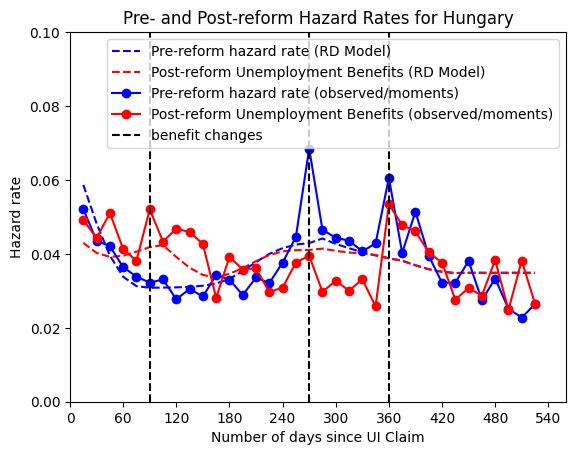

In [ ]:
plt.plot(timevec, opt_pre, label='Pre-reform hazard rate (RD Model)', linestyle='dashed', color='blue')
plt.plot(timevec, opt_post, label='Post-reform Unemployment Benefits (RD Model)', linestyle='dashed', color='red')
plt.plot(timevec, opt_emp_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='blue')
plt.plot(timevec, opt_emp_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='red')

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.ylim(0, 0.1) # set x-axis limits to first and last element in timevec
plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[6*15, 18*15, 24*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.show()

In [ ]:
asset_indices = [0, 5, 10, 25, 50, 75, 99]

for i in asset_indices:
    plt.plot(
        timevec_H,
        S_pre[i, :35],
        label=f"A = {a_grid[i]:.0f}"
    )

plt.xlabel("Days since UI claim")
plt.ylabel("Search effort")
plt.legend()
plt.show()

NameError: name 'plt' is not defined